In [ ]:
from datasets import load_dataset
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
# https://huggingface.co/datasets/TimSchopf/medical_abstracts


/Users/Kitu/anaconda3/envs/d266myassignment/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Define the label mapping
label_map = {
    1: "Neoplasms",
    2: "Digestive system diseases",
    3: "Nervous system diseases",
    4: "Cardiovascular diseases",
    5: "General pathological conditions",
}

# Load the dataset
# We'll load the 'train' split as an example
dataset = load_dataset("TimSchopf/medical_abstracts", split="train")

In [10]:
dataset["condition_label"]

Column([5, 1, 2, 1, 3])

In [11]:


# Define the mapping function
def map_label_to_text(example):
    """Replaces the numerical label with its corresponding text."""
    # Assuming the label column is named 'condition_label'
    example["condition_label"] = label_map[example["condition_label"]]
    return example


# Apply the map function to the dataset
# You can set 'num_proc' to a higher number for faster processing (if you have multiple cores)
dataset_with_text_labels = dataset.map(map_label_to_text)

# Inspect the result
print(dataset_with_text_labels[0])
# The 'condition_label' field will now contain the text label instead of the number.

Map: 100%|██████████| 11550/11550 [00:00<00:00, 19214.39 examples/s]

{'condition_label': 'General pathological conditions', 'medical_abstract': 'Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The aseptically loosened prosthesis provided a means for investigating the in vivo and in vitro activity of the cells associated with the loosening process in seven dogs. The cells were isolated and maintained in culture for sufficient periods of time so that their biologic activity could be studied as well as the effect of different agents added to the cells in vivo or in vitro. The biologic response as determined by interleukin-1 and prostaglandin E2 activity paralleled the roentgenographic appearance of loosening and the technetium images and observations made at the time of revision surgery. The correlation between clinical, roentgenographic, histologic, and biochemical loosening indicates that the canine model is suitable for investigating the mechanisms of prosthetic failure. A canine model perm

In [13]:
df = dataset_with_text_labels.to_pandas()
df

,condition_label,medical_abstract
0,General pathological conditions,Tissue changes around loose prostheses. A cani...
1,Neoplasms,Neuropeptide Y and neuron-specific enolase lev...
2,Digestive system diseases,"Sexually transmitted diseases of the colon, re..."
3,Neoplasms,Lipolytic factors associated with murine and h...
4,Nervous system diseases,Does carotid restenosis predict an increased r...
...,...,...
11545,Neoplasms,Epirubicin at two dose levels with prednisolon...
11546,Neoplasms,Four and a half year follow up of women with d...
11547,General pathological conditions,Safety of the transbronchial biopsy in outpati...
11548,Nervous system diseases,Interictal spikes and hippocampal somatostatin...


In [14]:
# Check distribution (imbalance)
rating_counts = df["condition_label"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

Class distribution:
 condition_label
Cardiovascular diseases            2441
Digestive system diseases          1195
General pathological conditions    3844
Neoplasms                          2530
Nervous system diseases            1540
Name: count, dtype: int64


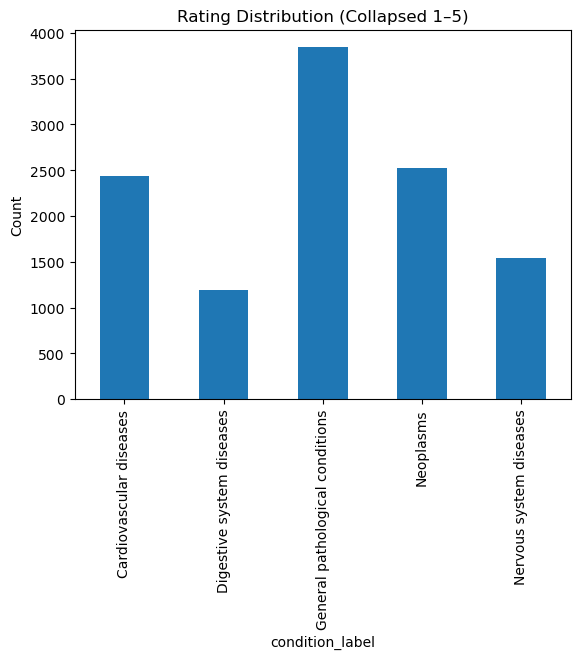

In [15]:
#df["rating_bucket"] = df["disease"]


# visualize the distribution
rating_counts.plot(kind="bar", title="Rating Distribution (Collapsed 1–5)")
plt.xlabel("condition_label")
plt.ylabel("Count")
plt.show()

In [17]:
# Balance dataset (undersample the majority class for demonstration)
min_count = rating_counts.min()
balanced_df = df.groupby("condition_label", group_keys=False).apply(
    lambda x: x.sample(min_count, random_state=42)
)

print("\nBalanced class distribution:\n", balanced_df["condition_label"].value_counts())


Balanced class distribution:
 condition_label
Cardiovascular diseases            1195
Digestive system diseases          1195
General pathological conditions    1195
Neoplasms                          1195
Nervous system diseases            1195
Name: count, dtype: int64


/var/folders/gj/bbgjz4_x5ybc58ms5zv9p8sr0000gp/T/ipykernel_42312/394233174.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("condition_label", group_keys=False).apply(


In [18]:
balanced_df.head(10)


,condition_label,medical_abstract
10961,Cardiovascular diseases,Infrainguinal revascularization for limb salva...
2948,Cardiovascular diseases,Monitoring of spinal cord stimulation evoked p...
10503,Cardiovascular diseases,Rarity of preclinical alcoholic cardiomyopathy...
7598,Cardiovascular diseases,Exercise intolerance in patients with heart fa...
11124,Cardiovascular diseases,The role of calcium channel blockers in the tr...
2333,Cardiovascular diseases,Effects of doxazosin on serum lipids: a review...
7410,Cardiovascular diseases,Transforming growth factor-beta activity in sh...
2893,Cardiovascular diseases,A case report of giant cell arteritis of the u...
4755,Cardiovascular diseases,An improved photochemical model of embolic cer...
1084,Cardiovascular diseases,Sudden death and sleeping history among Finnis...


In [19]:
# save the balanced dataset to you current directory
balanced_df.to_csv("medical_abstract.csv")

Class distribution:
 condition_label
Cardiovascular diseases            1195
Digestive system diseases          1195
General pathological conditions    1195
Neoplasms                          1195
Nervous system diseases            1195
Name: count, dtype: int64


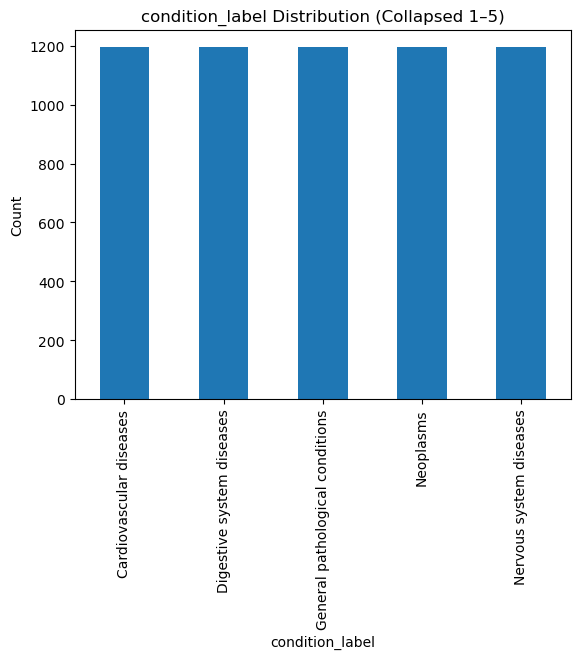

In [20]:
# Revalidate the balanced distribution
# Check distribution (imbalance)
rating_counts = balanced_df["condition_label"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

# visualize
rating_counts.plot(kind="bar", title="condition_label Distribution (Collapsed 1–5)")
plt.xlabel("condition_label")
plt.ylabel("Count")
plt.show()

In [21]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

text = "Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The aseptically loosened prosthesis provided a means for investigating the in vivo and in vitro activity of the cells associated with the loosening process in seven dogs. The cells were isolated and maintained in culture for sufficient periods of time so that their biologic activity could be studied as well as the effect of different agents added to the cells in vivo or in vitro. The biologic response as determined by interleukin-1 and prostaglandin E2 activity paralleled the roentgenographic appearance of loosening and the technetium images and observations made at the time of revision surgery. The correlation between clinical, roentgenographic, histologic, and biochemical loosening indicates that the canine model is suitable for investigating the mechanisms of prosthetic failure. A canine model permits the study of possible nonsurgical therapeutic interventions with the ultimate hope of stopping or slowing the loosening process."
candidate_labels = df["condition_label"]

result = classifier(text, candidate_labels)
print(result)

2025-10-02 17:59:22.340057: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


ValueError: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.